# F1 detection–action gap — two figures

Renders two standalone figures as cell outputs (pooled-of-4, LLM-judge primary DR, `reached_trap=True`; numbers from `paper_tables_v2.tex` / `tab:results-f1` / `app:per-model-f1-c3`).

- **Fig A** — detection–action gap across conditions (grouped bars).
- **Fig B** — per-model F1 gap at C3 (forest plot).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

COL_DR1, COL_DR0 = '#1a365d', '#bee3f8'      # dark navy / pale blue
COL_HL, COL_UNPWR = '#c53030', '#2b6cb0'     # red / blue
COL_GRID, COL_SPINE = '#e8edf2', '#cbd5e0'

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.titlepad': 9,
    'axes.labelcolor': '#2d3748', 'xtick.color': '#4a5568', 'ytick.color': '#4a5568',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# --- Fig A data: PLR_crit by DR-label x condition (pooled-of-4) ---
conditions = ['C0', 'C1', 'C2', 'C3']
dr1_vals = [6.8, 22.9, 30.0, 35.9]
dr0_vals = [82.5, 74.0, 69.4, 66.1]
n_dr1 = [88, 140, 257, 462]
C3_GAP = 30.2

# --- Fig B data: per-model + pooled F1 gap at C3 (ordered by gap, desc) ---
#   (label, gap_pp, n_DR1, ci_lo, ci_hi, powered)
rows = [
    ('Llama 4 Scout',    38.3,  70, 26.1, 50.6, False),
    ('Pooled-of-4',      30.2, 462, 25.0, 35.4, True ),
    ('Claude Haiku 4.5', 21.1, 122, 11.6, 30.7, False),
    ('GPT-5 mini',       19.4, 167,  9.5, 29.3, False),
    ('Gemini 3 Flash',   17.2, 103,  6.3, 28.0, False),
]

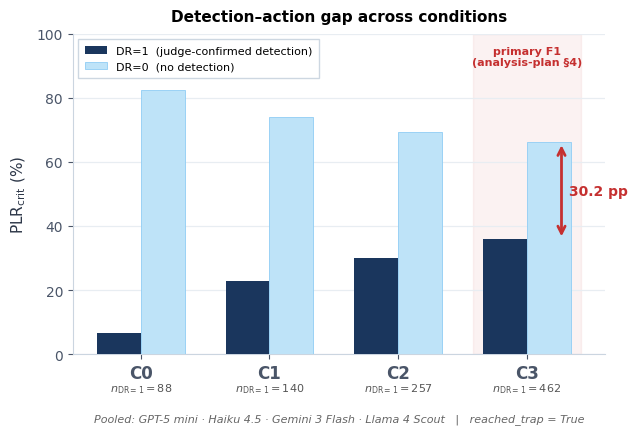

In [5]:
# =====================================================================
# FIG A -- detection-action gap across conditions
# =====================================================================
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x, width = np.arange(4), 0.34

# shaded band behind the C3 (primary) pair
ax.axvspan(3 - 0.42, 3 + 0.42, color=COL_HL, alpha=0.06, zorder=0)

ax.bar(x - width/2, dr1_vals, width, label='DR=1  (judge-confirmed detection)',
       color=COL_DR1, zorder=3)
ax.bar(x + width/2, dr0_vals, width, label='DR=0  (no detection)',
       color=COL_DR0, edgecolor='#90cdf4', linewidth=0.6, zorder=3)

ax.set_ylim(0, 100)
ax.set_ylabel('PLR$_{\\mathrm{crit}}$ (%)', fontsize=11, labelpad=6)
ax.set_xticks(x); ax.set_xticklabels(conditions, fontsize=12, fontweight='bold')
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.grid(True, color=COL_GRID, zorder=0, linewidth=0.9); ax.set_axisbelow(True)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color(COL_SPINE)
ax.legend(fontsize=8, loc='upper left', framealpha=0.95, edgecolor=COL_SPINE,
          fancybox=False, borderpad=0.6)

# n_DR=1 labels under each condition
for xi, n in zip(x, n_dr1):
    ax.text(xi, -8.5, f'$n_{{\\mathrm{{DR=1}}}}={n}$', ha='center', va='top',
            fontsize=8, color='#555')

# C3 gap arrow + label
arr_x = 3 + width/2 + 0.10
ax.annotate('', xy=(arr_x, dr0_vals[3]), xytext=(arr_x, dr1_vals[3]),
            arrowprops=dict(arrowstyle='<->', color=COL_HL, lw=2.0, mutation_scale=13))
ax.text(arr_x + 0.06, (dr1_vals[3] + dr0_vals[3]) / 2, f'{C3_GAP} pp',
        color=COL_HL, fontsize=10, fontweight='bold', va='center')

# 'primary F1' label at the top of the C3 band
ax.text(3, 96, 'primary F1\n(analysis-plan §4)', ha='center', va='top',
        fontsize=8, color=COL_HL, fontweight='bold', linespacing=1.1)

ax.set_title('Detection–action gap across conditions', fontsize=11, fontweight='bold')
ax.text(0.5, -0.20,
        'Pooled: GPT-5 mini · Haiku 4.5 · Gemini 3 Flash · Llama 4 Scout   |   reached_trap = True',
        ha='center', va='center', transform=ax.transAxes, fontsize=8, color='#666', style='italic')

plt.tight_layout()
plt.show()

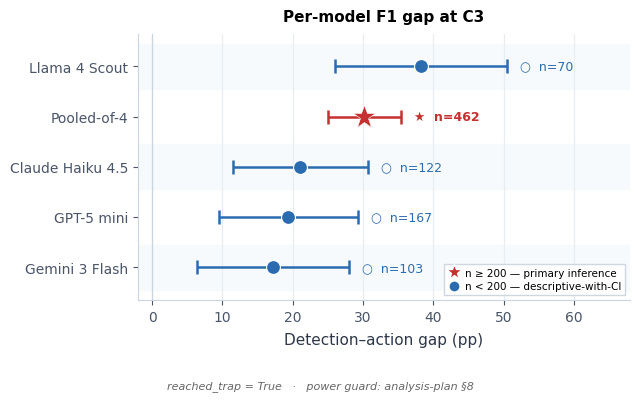

In [6]:
# =====================================================================
# FIG B -- per-model F1 gap at C3 (forest plot)
# =====================================================================
fig, ax = plt.subplots(figsize=(6.5, 4.0))
y_pos = list(range(len(rows) - 1, -1, -1))   # top row = first entry

for yi in y_pos:
    ax.axhspan(yi - 0.45, yi + 0.45, color='#f7fafc' if yi % 2 == 0 else 'white', zorder=0)
ax.axvline(0, color=COL_SPINE, lw=0.9, zorder=1)

for yi, (label, gap, n1, lo, hi, pwr) in zip(y_pos, rows):
    col = COL_HL if pwr else COL_UNPWR
    ax.errorbar(gap, yi, xerr=(hi - lo) / 2, fmt='none', color=col,
                capsize=5, capthick=1.8, lw=1.8, zorder=3)
    if pwr:
        ax.plot(gap, yi, marker='*', color=COL_HL, markersize=17, zorder=4,
                markeredgecolor='white', markeredgewidth=0.4)
    else:
        ax.plot(gap, yi, marker='o', color=COL_UNPWR, markersize=10, zorder=4,
                markeredgecolor='white', markeredgewidth=0.8)
    sym = '★' if pwr else '○'
    ax.text(hi + 1.8, yi, f'{sym}  n={n1}', va='center', ha='left', fontsize=9,
            color=col, fontweight='bold' if pwr else 'normal')

ax.set_xlim(-2, 68); ax.set_ylim(-0.65, len(rows) - 0.35)
ax.set_yticks(y_pos); ax.set_yticklabels([r[0] for r in rows], fontsize=10)
ax.set_xlabel('Detection–action gap (pp)', fontsize=11, labelpad=6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.grid(True, color=COL_GRID, zorder=0, linewidth=0.9); ax.set_axisbelow(True)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax.spines[sp].set_color(COL_SPINE)

ax.set_title('Per-model F1 gap at C3', fontsize=11, fontweight='bold')

legend_elems = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor=COL_HL, markersize=12,
           label='n ≥ 200 — primary inference'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COL_UNPWR, markersize=8,
           label='n < 200 — descriptive-with-CI'),
]
ax.legend(handles=legend_elems, fontsize=7.5, loc='lower right', framealpha=0.93,
          edgecolor=COL_SPINE, fancybox=False, borderpad=0.35, labelspacing=0.3,
          handletextpad=0.4, handlelength=1.2)

# context note in reserved bottom margin (below the x-axis label, no overlap)
fig.text(0.5, 0.015, 'reached_trap = True   ·   power guard: analysis-plan §8',
         ha='center', fontsize=8, color='#666', style='italic')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()